# Q-Harm Thermodynamic Filter Statistics and Coverage

This notebook counts the complete LB–B design space and the subsequent LB–B + C–Cl reaction space using the released CSV files.

The cutoff is applied strictly as `< -4.1 kcal/mol` to:

1. Q-Harm-corrected LB–B combination free energy, `deltaG_comb_qharm(kcal/mol)`.
2. Q-Harm-corrected reaction free energy, `Delta G_rxn = (deltaG_react_qharm(LB-B) + deltaG_react_qharm(C-Cl)) * 627.509`.

Rows marked `Experiment == 1` in `reactants_Cl.csv` are external extrapolation-validation substrates and are explicitly excluded from the reaction design space before counting or screening.

The second screened quantity is a **reaction free energy**, not an activation barrier (`Delta G^‡`). The notebook prints reviewer-runnable audits and saves the coverage and final-type-distribution figures; it writes no additional CSV files.

## Setup

All paths are resolved from the repository root. The constants and strict inequality are kept in one cell for a reproducible rerun.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "Data" / "csvs" / "reactants_B.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root containing Data/csvs.")


PROJECT_ROOT = find_project_root()
CSV_DIR = PROJECT_ROOT / "Data" / "csvs"
FIGURE_DIR = PROJECT_ROOT / "Figure"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_KCAL = -4.1
HARTREE_TO_KCAL = 627.509
FIGURE_PATH = FIGURE_DIR / "OtherFigure_QHARM_thermodynamic_filter_coverage.png"
TYPE_DISTRIBUTION_FIGURE_PATH = FIGURE_DIR / "OtherFigure_QHARM_filtered_type_distribution.png"

print("Project root:", PROJECT_ROOT)
print(f"Strict Q-Harm cutoff: Delta G < {THRESHOLD_KCAL:.1f} kcal/mol")

Project root: d:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database
Strict Q-Harm cutoff: Delta G < -4.1 kcal/mol


## 1. LB–B combination count

The theoretical total is calculated directly from all rows in `reactants_B.csv` and `reactants_N.csv`. Q-Harm results and missing-value auditing come from `reactants_B_N_full.csv`, which retains one row for every theoretical LB–B entry.

In [5]:
b_df = pd.read_csv(CSV_DIR / "reactants_B.csv")
n_df = pd.read_csv(CSV_DIR / "reactants_N.csv")
bn_full_df = pd.read_csv(CSV_DIR / "reactants_B_N_full.csv")

PAIR_KEYS = ["B_Index", "B_Atomid", "N_Index", "N_Atomid"]
BN_COMB_COLUMN = "deltaG_comb_qharm(kcal/mol)"
BN_RXN_COLUMN = "deltaG_react_qharm"

for column in (BN_COMB_COLUMN, BN_RXN_COLUMN):
    bn_full_df[column] = pd.to_numeric(bn_full_df[column], errors="coerce")

total_bn_combinations = len(b_df) * len(n_df)
assert len(bn_full_df) == total_bn_combinations, (
    "reactants_B_N_full.csv does not contain one row per B-row x N-row combination."
)
assert not bn_full_df.duplicated(PAIR_KEYS).any(), (
    "Duplicate LB-B identities found when atom-site identifiers are included."
)

bn_qharm_evaluable = bn_full_df[BN_COMB_COLUMN].notna()
bn_pass_mask = bn_qharm_evaluable & (bn_full_df[BN_COMB_COLUMN] < THRESHOLD_KCAL)
bn_pass_df = bn_full_df.loc[bn_pass_mask].copy()

print("1) LB-B combination screen")
print(f"   B rows: {len(b_df):,}")
print(f"   LB rows: {len(n_df):,}")
print(f"   Total LB-B combinations: {total_bn_combinations:,}")
print(f"   Q-Harm evaluable: {bn_qharm_evaluable.sum():,}")
print(f"   Missing Q-Harm combination energy: {(~bn_qharm_evaluable).sum():,}")
print(f"   Pass Delta G_comb,QH < {THRESHOLD_KCAL:.1f}: {bn_pass_mask.sum():,}")
print(f"   Evaluable but not passing: {(bn_qharm_evaluable & ~bn_pass_mask).sum():,}")

1) LB-B combination screen
   B rows: 55
   LB rows: 415
   Total LB-B combinations: 22,825
   Q-Harm evaluable: 20,010
   Missing Q-Harm combination energy: 2,815
   Pass Delta G_comb,QH < -4.1: 19,974
   Evaluable but not passing: 36


## 2. LB–B + C–Cl reaction count

Rows with `Experiment == 1` are the two external extrapolation-validation substrates and are excluded before constructing the reaction space. Every LB–B pair passing step 1 is then combined with each remaining database-screening C–Cl substrate. A Q-Harm missing-value audit is retained as a guard against silently treating missing thermochemistry as a failed reaction.

In [6]:
cl_all_df = pd.read_csv(CSV_DIR / "reactants_Cl.csv")
CL_RXN_COLUMN = "deltaG_react_qharm"
EXTERNAL_VALIDATION_COLUMN = "Experiment"

cl_all_df[CL_RXN_COLUMN] = pd.to_numeric(cl_all_df[CL_RXN_COLUMN], errors="coerce")
cl_all_df[EXTERNAL_VALIDATION_COLUMN] = pd.to_numeric(
    cl_all_df[EXTERNAL_VALIDATION_COLUMN], errors="coerce"
).fillna(0)

external_validation_mask = cl_all_df[EXTERNAL_VALIDATION_COLUMN].eq(1)
external_validation_cl_df = cl_all_df.loc[external_validation_mask].copy()
cl_df = cl_all_df.loc[~external_validation_mask].copy()

assert len(external_validation_cl_df) == 2, (
    "Expected exactly two Experiment == 1 external-validation C-Cl substrates."
)

bn_reaction_evaluable = bn_pass_df[BN_RXN_COLUMN].notna()
cl_reaction_evaluable = cl_df[CL_RXN_COLUMN].notna()
bn_rxn_df = bn_pass_df.loc[bn_reaction_evaluable].reset_index(drop=True)
cl_rxn_df = cl_df.loc[cl_reaction_evaluable].reset_index(drop=True)

# Shape: (thermodynamically stable LB-B pairs, screening-set C-Cl substrates).
reaction_dg_qharm = (
    bn_rxn_df[BN_RXN_COLUMN].to_numpy(dtype=float)[:, None]
    + cl_rxn_df[CL_RXN_COLUMN].to_numpy(dtype=float)[None, :]
) * HARTREE_TO_KCAL
reaction_pass_mask = reaction_dg_qharm < THRESHOLD_KCAL

total_reaction_combinations = len(bn_pass_df) * len(cl_df)
evaluable_reaction_combinations = reaction_dg_qharm.size
missing_reaction_combinations = total_reaction_combinations - evaluable_reaction_combinations
passed_reaction_combinations = int(reaction_pass_mask.sum())
failed_reaction_combinations = evaluable_reaction_combinations - passed_reaction_combinations

print("2) LB-B + C-Cl reaction screen")
print(
    "   External-validation C-Cl substrates excluded: "
    f"{len(external_validation_cl_df):,} "
    f"(Index {external_validation_cl_df['Index'].astype(int).tolist()})"
)
print(f"   Step-1-passing LB-B combinations: {len(bn_pass_df):,}")
print(f"   Screening-set C-Cl substrate rows: {len(cl_df):,}")
print(f"   Total LB-B + C-Cl combinations: {total_reaction_combinations:,}")
print(f"   Q-Harm evaluable: {evaluable_reaction_combinations:,}")
print(f"   Missing Q-Harm reaction energy after exclusion: {missing_reaction_combinations:,}")
print(f"   Pass Delta G_rxn,QH < {THRESHOLD_KCAL:.1f}: {passed_reaction_combinations:,}")
print(f"   Evaluable but not passing: {failed_reaction_combinations:,}")

2) LB-B + C-Cl reaction screen
   External-validation C-Cl substrates excluded: 2 (Index [723, 724])
   Step-1-passing LB-B combinations: 19,974
   Screening-set C-Cl substrate rows: 179
   Total LB-B + C-Cl combinations: 3,575,346
   Q-Harm evaluable: 3,575,346
   Missing Q-Harm reaction energy after exclusion: 0
   Pass Delta G_rxn,QH < -4.1: 3,014,127
   Evaluable but not passing: 561,219


## 3. Figure 5A-style screening summary and coverage checks

The screening pies and distribution reproduce the compact summary style of Figure 5A for **all database-screening Q-Harm candidates after excluding external-validation substrates**. The 3D panel gives an aggregate coverage view. Each LB–B point represents all valid C–Cl partners through its height (number passed) and color (fraction passed), so no random downsampling is used.

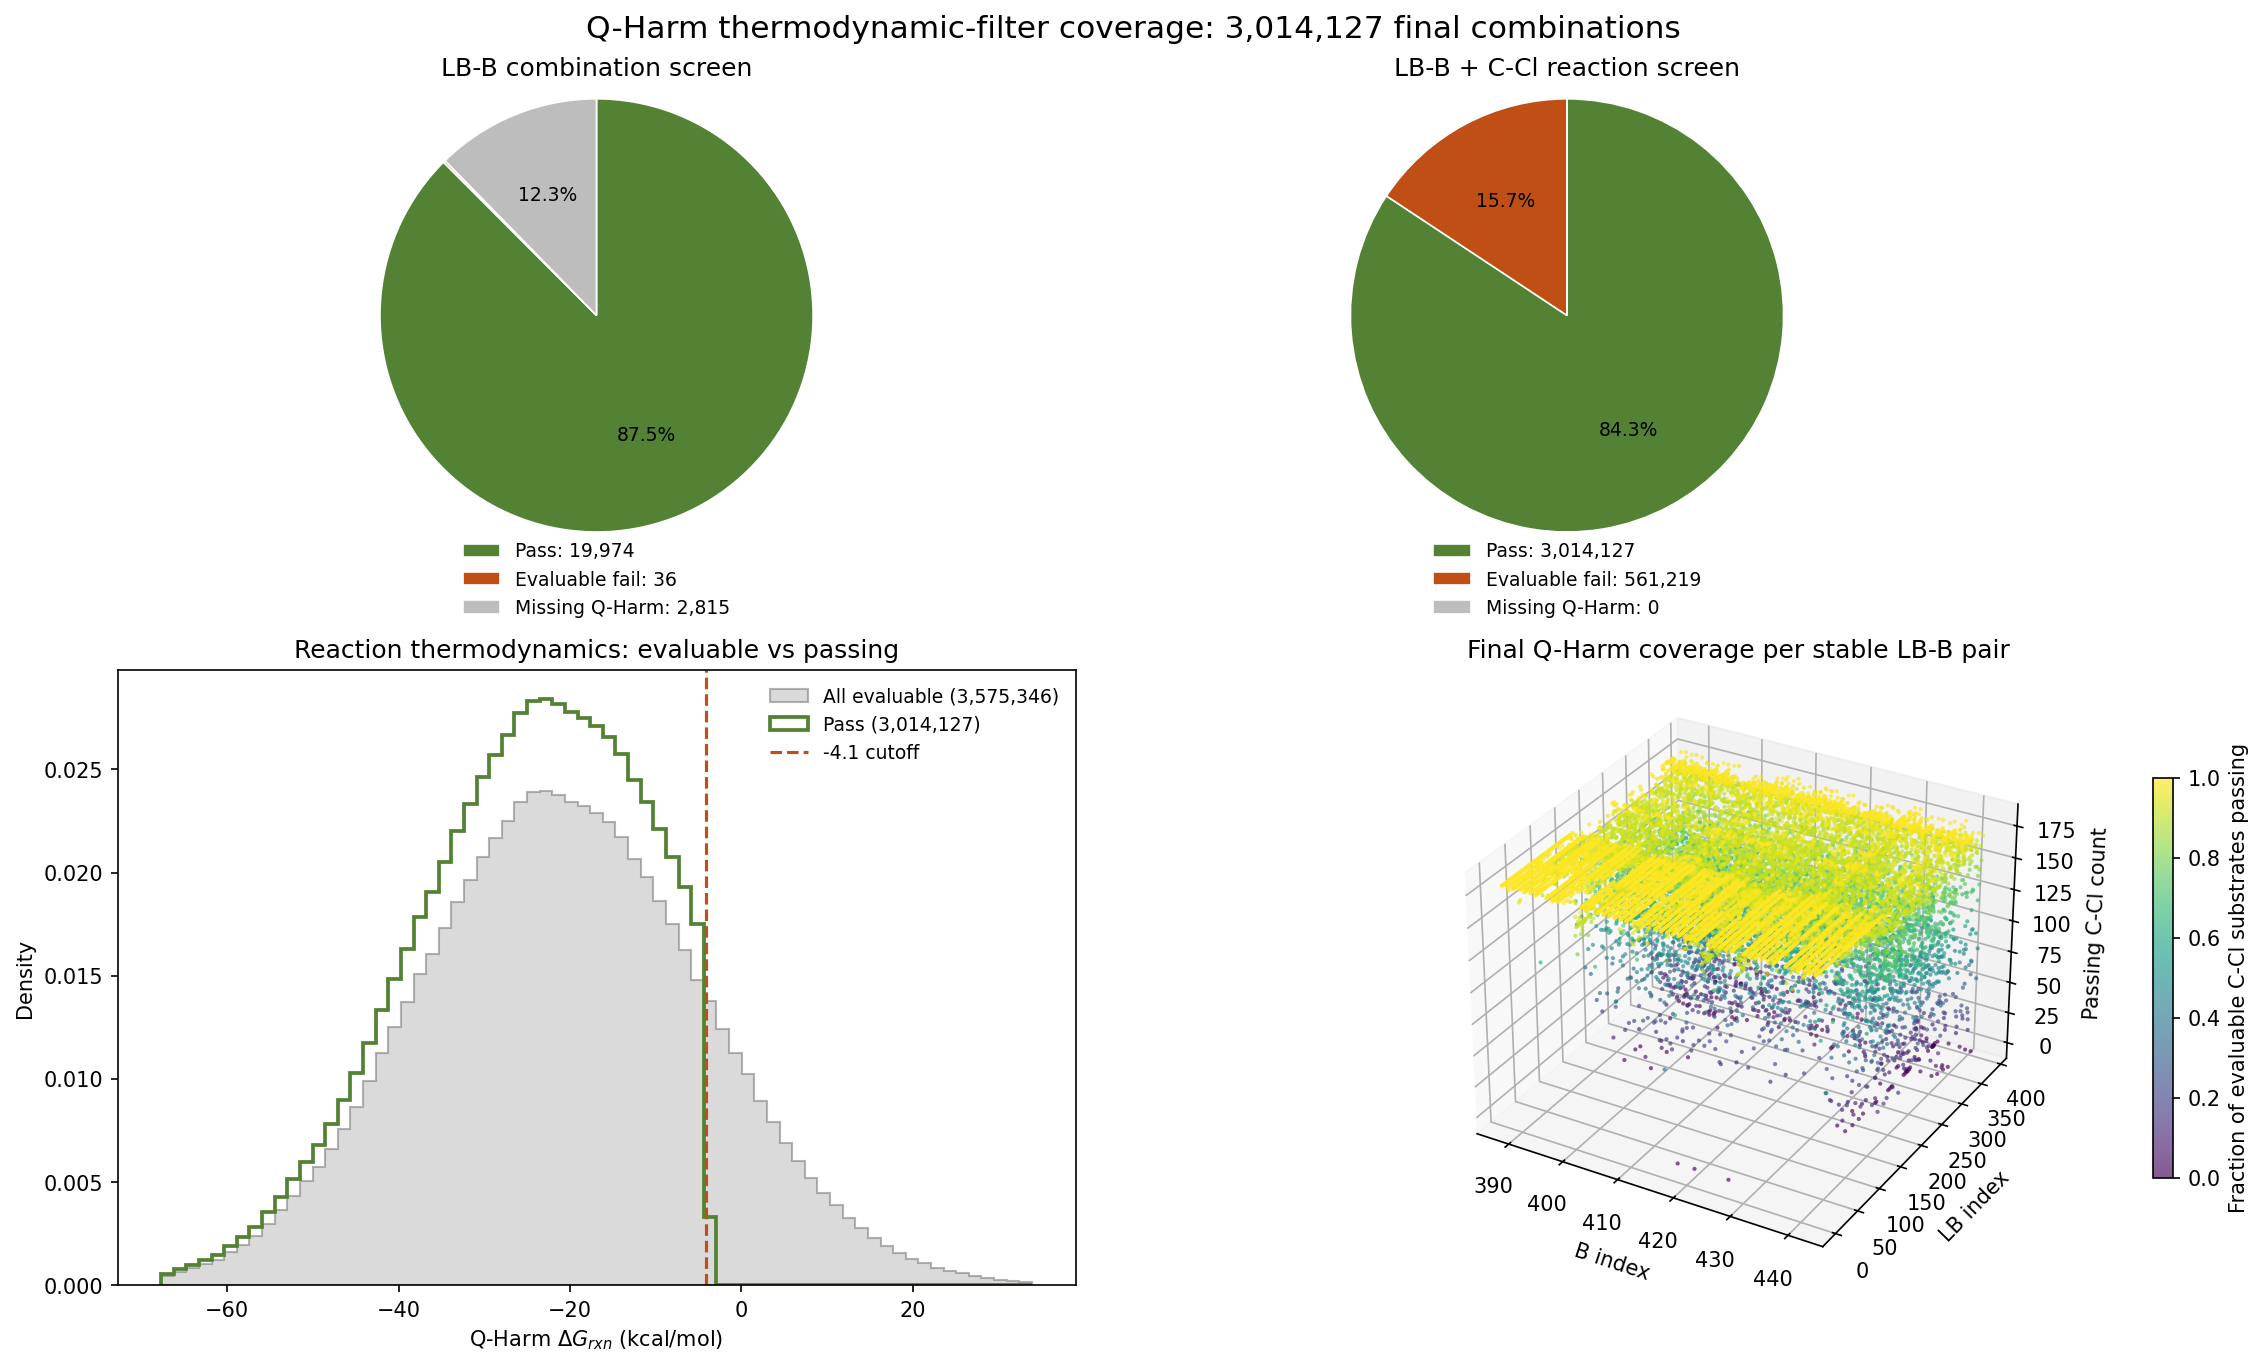

3) Figure saved: d:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\OtherFigure_QHARM_thermodynamic_filter_coverage.png


In [7]:
# Exact coverage across every Q-Harm-evaluable LB-B + C-Cl combination.
passes_per_bn = reaction_pass_mask.sum(axis=1).astype(np.int64)


def plot_screen_pie(ax, values, labels, title, colors):
    wedges, _, _ = ax.pie(
        values,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
        textprops={"fontsize": 9},
        wedgeprops={"edgecolor": "white", "linewidth": 0.8},
    )
    legend_labels = [f"{label}: {value:,}" for label, value in zip(labels, values)]
    ax.legend(wedges, legend_labels, loc="lower center", bbox_to_anchor=(0.5, -0.20), frameon=False, fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.axis("equal")


fig = plt.figure(figsize=(15, 9), dpi=150, constrained_layout=True)
grid = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.35])

ax_bn_pie = fig.add_subplot(grid[0, 0:3])
ax_rxn_pie = fig.add_subplot(grid[0, 3:6])
plot_screen_pie(
    ax_bn_pie,
    [int(bn_pass_mask.sum()), int((bn_qharm_evaluable & ~bn_pass_mask).sum()), int((~bn_qharm_evaluable).sum())],
    ["Pass", "Evaluable fail", "Missing Q-Harm"],
    "LB-B combination screen",
    ["#548235", "#c04f15", "#bdbdbd"],
)
plot_screen_pie(
    ax_rxn_pie,
    [passed_reaction_combinations, failed_reaction_combinations, missing_reaction_combinations],
    ["Pass", "Evaluable fail", "Missing Q-Harm"],
    "LB-B + C-Cl reaction screen",
    ["#548235", "#c04f15", "#bdbdbd"],
)

# Distribution analogous to the TS-vs-all thermodynamic coverage plot.
ax_hist = fig.add_subplot(grid[1, 0:3])
finite_dg = reaction_dg_qharm.ravel()
hist_min, hist_max = np.nanpercentile(finite_dg, [0.1, 99.9])
bins = np.linspace(hist_min, hist_max, 70)
ax_hist.hist(
    finite_dg,
    bins=bins,
    density=True,
    histtype="stepfilled",
    color="#bdbdbd",
    alpha=0.55,
    edgecolor="#777777",
    linewidth=1.0,
    label=f"All evaluable ({evaluable_reaction_combinations:,})",
)
ax_hist.hist(
    finite_dg[finite_dg < THRESHOLD_KCAL],
    bins=bins,
    density=True,
    histtype="step",
    color="#548235",
    linewidth=1.8,
    label=f"Pass ({passed_reaction_combinations:,})",
)
ax_hist.axvline(THRESHOLD_KCAL, color="#c04f15", linestyle="--", linewidth=1.5, label="-4.1 cutoff")
ax_hist.set_xlabel(r"Q-Harm $\Delta G_{rxn}$ (kcal/mol)")
ax_hist.set_ylabel("Density")
ax_hist.set_title("Reaction thermodynamics: evaluable vs passing")
ax_hist.legend(frameon=False, fontsize=9)

# Aggregate 3D coverage: every stable LB-B pair is included; z/color summarize all Cl partners.
ax_3d = fig.add_subplot(grid[1, 3:6], projection="3d")
cl_denominator = len(cl_rxn_df)
coverage_fraction = passes_per_bn / cl_denominator
scatter = ax_3d.scatter(
    bn_rxn_df["B_Index"],
    bn_rxn_df["N_Index"],
    passes_per_bn,
    c=coverage_fraction,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=4,
    alpha=0.65,
    linewidths=0,
    rasterized=True,
)
ax_3d.set_xlabel("B index")
ax_3d.set_ylabel("LB index")
ax_3d.set_zlabel("Passing C-Cl count")
ax_3d.set_title("Final Q-Harm coverage per stable LB-B pair")
cbar = fig.colorbar(scatter, ax=ax_3d, shrink=0.65, pad=0.08)
cbar.set_label("Fraction of evaluable C-Cl substrates passing")

fig.suptitle(
    f"Q-Harm thermodynamic-filter coverage: {passed_reaction_combinations:,} final combinations",
    fontsize=15,
)
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("3) Figure saved:", FIGURE_PATH)

## 4. Final B, LB, and C–Cl type distributions [REVIEWER-RUNNABLE]

This section applies the same category definitions and ordering used by `6_Draw_Figures.ipynb` for Figure 5A. It reports the composition of the **3,014,127 final combinations** passing both strict Q-Harm filters.

Counts are obtained directly from the Boolean pass matrix: each passing C–Cl partner contributes once to its B and LB categories, and each passing LB–B partner contributes once to its C–Cl category. This gives exact proportions without materializing a 3,014,127-row table.

In [16]:
from DFTStructureGenerator.Build_DataBase import (
    B_TYPE_ORDER,
    CL_SUBSTRATE_TYPE_ORDER,
    LB_TYPE_ORDER,
    get_boron_type,
    get_cl_substrate_type,
    get_lb_type,
)


EXPECTED_FINAL_COMBINATIONS = 3_014_127
assert passed_reaction_combinations == EXPECTED_FINAL_COMBINATIONS, (
    f"Expected {EXPECTED_FINAL_COMBINATIONS:,} final combinations, "
    f"but reproduced {passed_reaction_combinations:,}."
)

# Row/column sums preserve every passing reaction while avoiding a large long-form table.
passes_per_bn = reaction_pass_mask.sum(axis=1).astype(np.int64)
passes_per_cl = reaction_pass_mask.sum(axis=0).astype(np.int64)

bn_type_df = bn_rxn_df[["B_smiles", "N_Index"]].copy()
bn_type_df["B_type"] = bn_type_df["B_smiles"].map(get_boron_type)
bn_type_df["LB_type"] = bn_type_df["N_Index"].map(get_lb_type)
cl_type_df = cl_rxn_df[["Smiles"]].copy()
cl_type_df["Cl_type"] = cl_type_df["Smiles"].map(get_cl_substrate_type)


def weighted_type_counts(labels, weights, order, family):
    labels = pd.Series(labels).reset_index(drop=True)
    weights = np.asarray(weights, dtype=np.int64)
    assert len(labels) == len(weights), f"{family}: label/weight length mismatch."
    assert labels.notna().all(), f"{family}: missing type labels."
    unexpected = sorted(set(labels) - set(order))
    assert not unexpected, f"{family}: unexpected type labels: {unexpected}"

    counts = (
        pd.DataFrame({"Type": labels, "Count": weights})
        .groupby("Type", observed=True)["Count"]
        .sum()
        .reindex(order, fill_value=0)
        .astype(np.int64)
    )
    # assert int(counts.sum()) == passed_reaction_combinations, (
    #     f"{family}: category counts do not sum to the final passing total."
    # )
    return counts


b_type_counts = weighted_type_counts(
    bn_type_df["B_type"], passes_per_bn, B_TYPE_ORDER, "B"
)
lb_type_counts = weighted_type_counts(
    bn_type_df["LB_type"], passes_per_bn, LB_TYPE_ORDER, "LB"
)
cl_type_counts = weighted_type_counts(
    cl_type_df["Cl_type"], passes_per_cl, CL_SUBSTRATE_TYPE_ORDER, "Cl"
)

distribution_frames = []
for family, counts in [
    ("B", b_type_counts),
    ("LB", lb_type_counts),
    ("Cl", cl_type_counts),
]:
    family_df = counts.rename("Count").to_frame().reset_index()
    family_df.insert(0, "Family", family)
    family_df["Share (%)"] = family_df["Count"] / passed_reaction_combinations * 100
    distribution_frames.append(family_df)

final_type_distribution_df = pd.concat(distribution_frames, ignore_index=True)
print(f"4) Type distribution across {passed_reaction_combinations:,} final combinations")
print(
    final_type_distribution_df.to_string(
        index=False,
        formatters={"Count": "{:,}".format, "Share (%)": "{:.2f}".format},
    )
)
display(final_type_distribution_df.style.format({"Count": "{:,}", "Share (%)": "{:.2f}"}))

4) Type distribution across 3,014,127 final combinations
Family         Type     Count Share (%)
     B          BR3         0      0.00
     B         R2BH 1,205,928     40.01
     B         RBH2 1,747,148     57.97
     B          BH3    61,051      2.03
    LB Amine/Aryl N 1,633,348     54.19
    LB    Phosphine   686,982     22.79
    LB          NHC   693,797     23.02
    Cl         CCl4    19,506      0.65
    Cl         CCl3   700,446     23.24
    Cl         CCl2   722,704     23.98
    Cl          CCl 1,571,471     52.14


,Family,Type,Count,Share (%)
0,B,BR3,0,0.00
1,B,R2BH,"1,205,928",40.01
2,B,RBH2,"1,747,148",57.97
3,B,BH3,"61,051",2.03
4,LB,Amine/Aryl N,"1,633,348",54.19
5,LB,Phosphine,"686,982",22.79
6,LB,NHC,"693,797",23.02
7,Cl,CCl4,"19,506",0.65
8,Cl,CCl3,"700,446",23.24
9,Cl,CCl2,"722,704",23.98


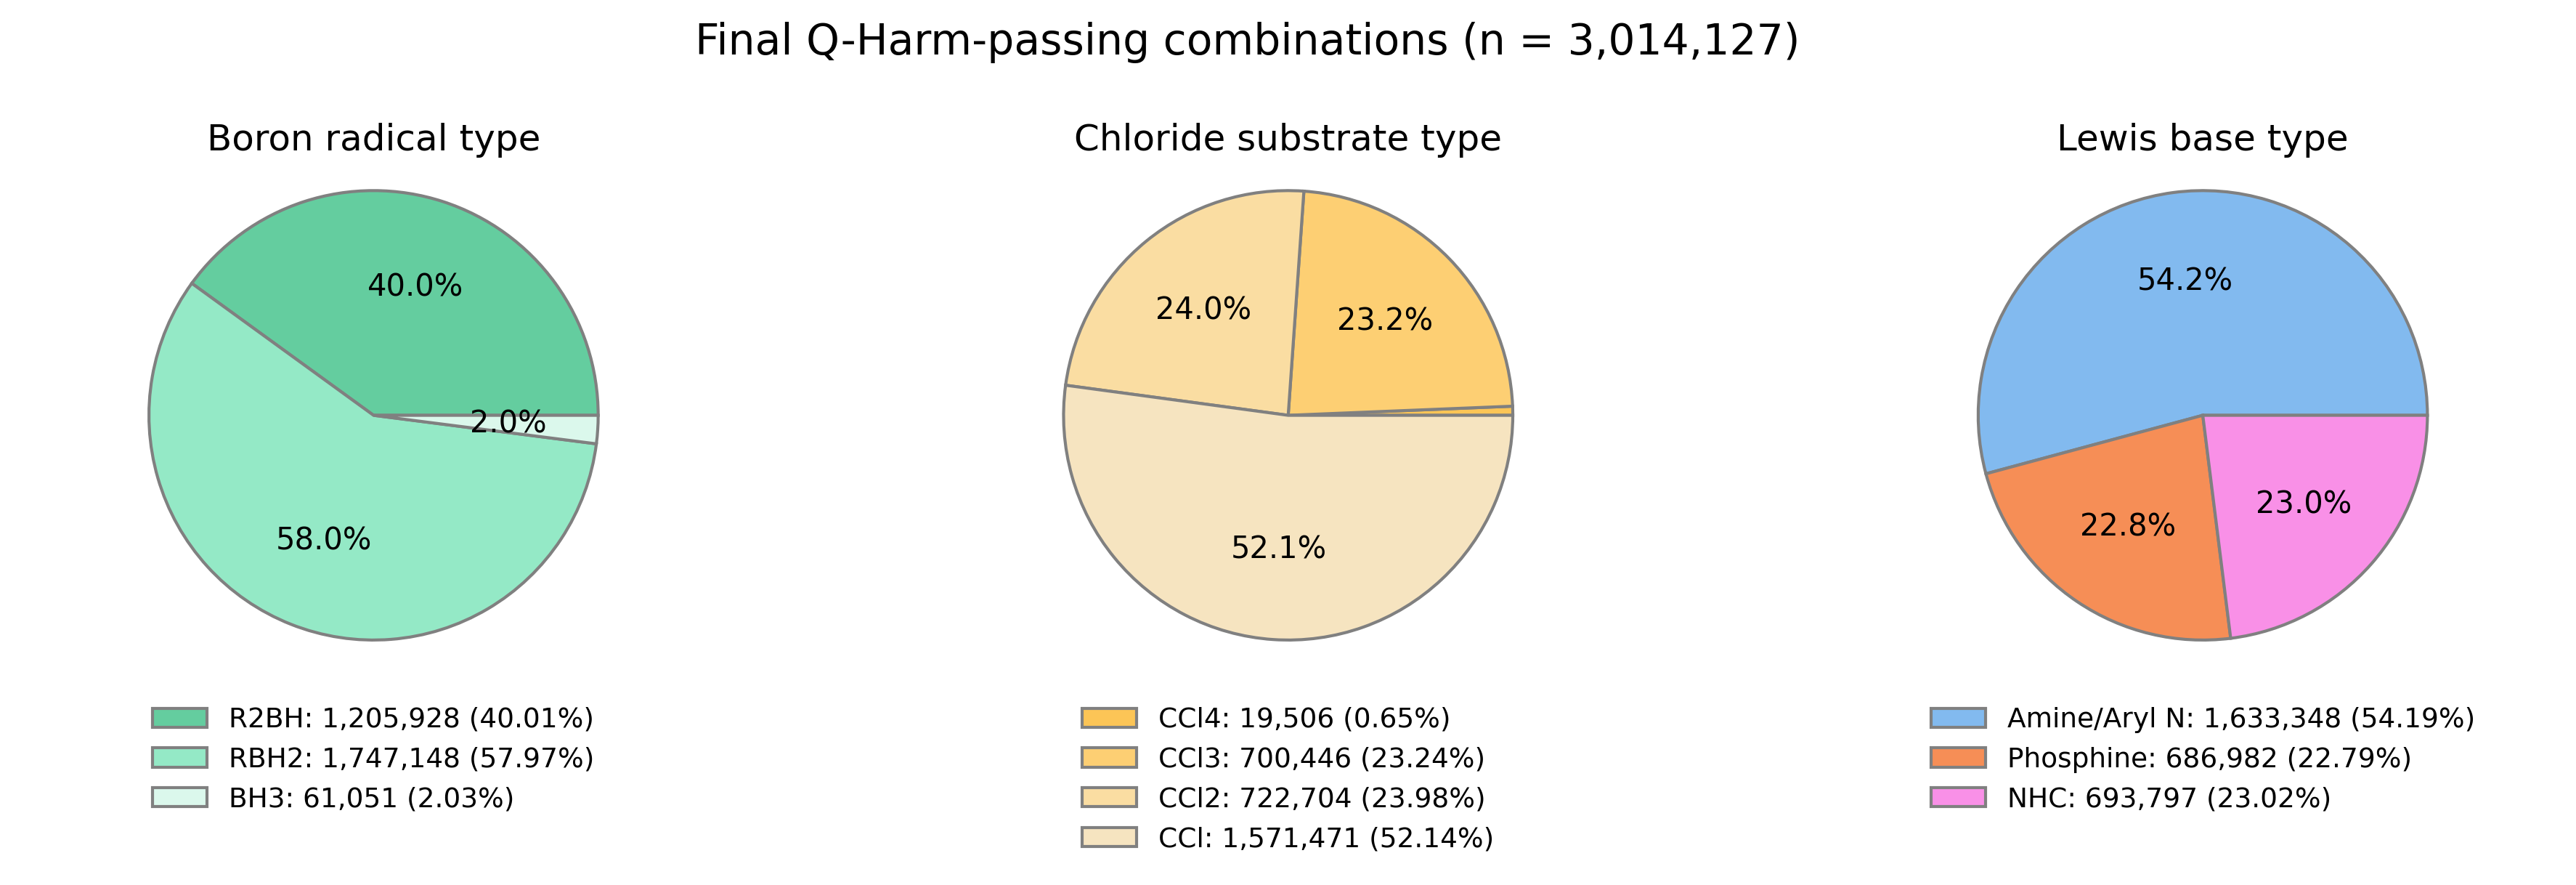

   Type-distribution figure saved: d:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\OtherFigure_QHARM_filtered_type_distribution.png


In [9]:
def plot_final_type_pie(ax, counts, title, colors):
    nonzero_counts = counts[counts > 0]
    color_by_type = dict(zip(counts.index, colors))
    pie_colors = [color_by_type[type_name] for type_name in nonzero_counts.index]
    wedges, _, _ = ax.pie(
        nonzero_counts.values,
        colors=pie_colors,
        startangle=0,
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
        textprops={"fontsize": 10},
        wedgeprops={"edgecolor": "gray", "linewidth": 1},
    )
    legend_labels = [
        f"{type_name}: {count:,} ({count / passed_reaction_combinations * 100:.2f}%)"
        for type_name, count in nonzero_counts.items()
    ]
    ax.legend(
        wedges,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
        fontsize=9,
    )
    ax.set_title(title, fontsize=12)
    ax.axis("equal")


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=300)
plot_final_type_pie(
    axes[0],
    b_type_counts,
    "Boron radical type",
    ["#3f9d70", "#64cd9f", "#94e9c6", "#dbf8ec"],
)
plot_final_type_pie(
    axes[1],
    cl_type_counts,
    "Chloride substrate type",
    ["#fcc556", "#fdcf73", "#fadda2", "#f6e4c0"],
)
plot_final_type_pie(
    axes[2],
    lb_type_counts,
    "Lewis base type",
    ["#82baef", "#f68e56", "#f990e7"],
)
fig.suptitle(
    f"Final Q-Harm-passing combinations (n = {passed_reaction_combinations:,})",
    fontsize=14,
)
fig.subplots_adjust(bottom=0.28, top=0.82, wspace=0.30)
fig.savefig(TYPE_DISTRIBUTION_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("   Type-distribution figure saved:", TYPE_DISTRIBUTION_FIGURE_PATH)

## End state

The printed audit distinguishes theoretical totals, Q-Harm-evaluable entries, missing thermochemistry, strict-cutoff passes, and the exact B/LB/C–Cl composition of the final 3,014,127 combinations. The notebook saves two PNG figures: the coverage summary and the final type-distribution pies.

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Jackie\AppData\Local\Temp\ipykernel_21116\1206768277.py:1: SyntaxWarning: invalid escape sequence '\c'
  all_type_df = pd.read_csv("Data\csvs\First_12000.csv")


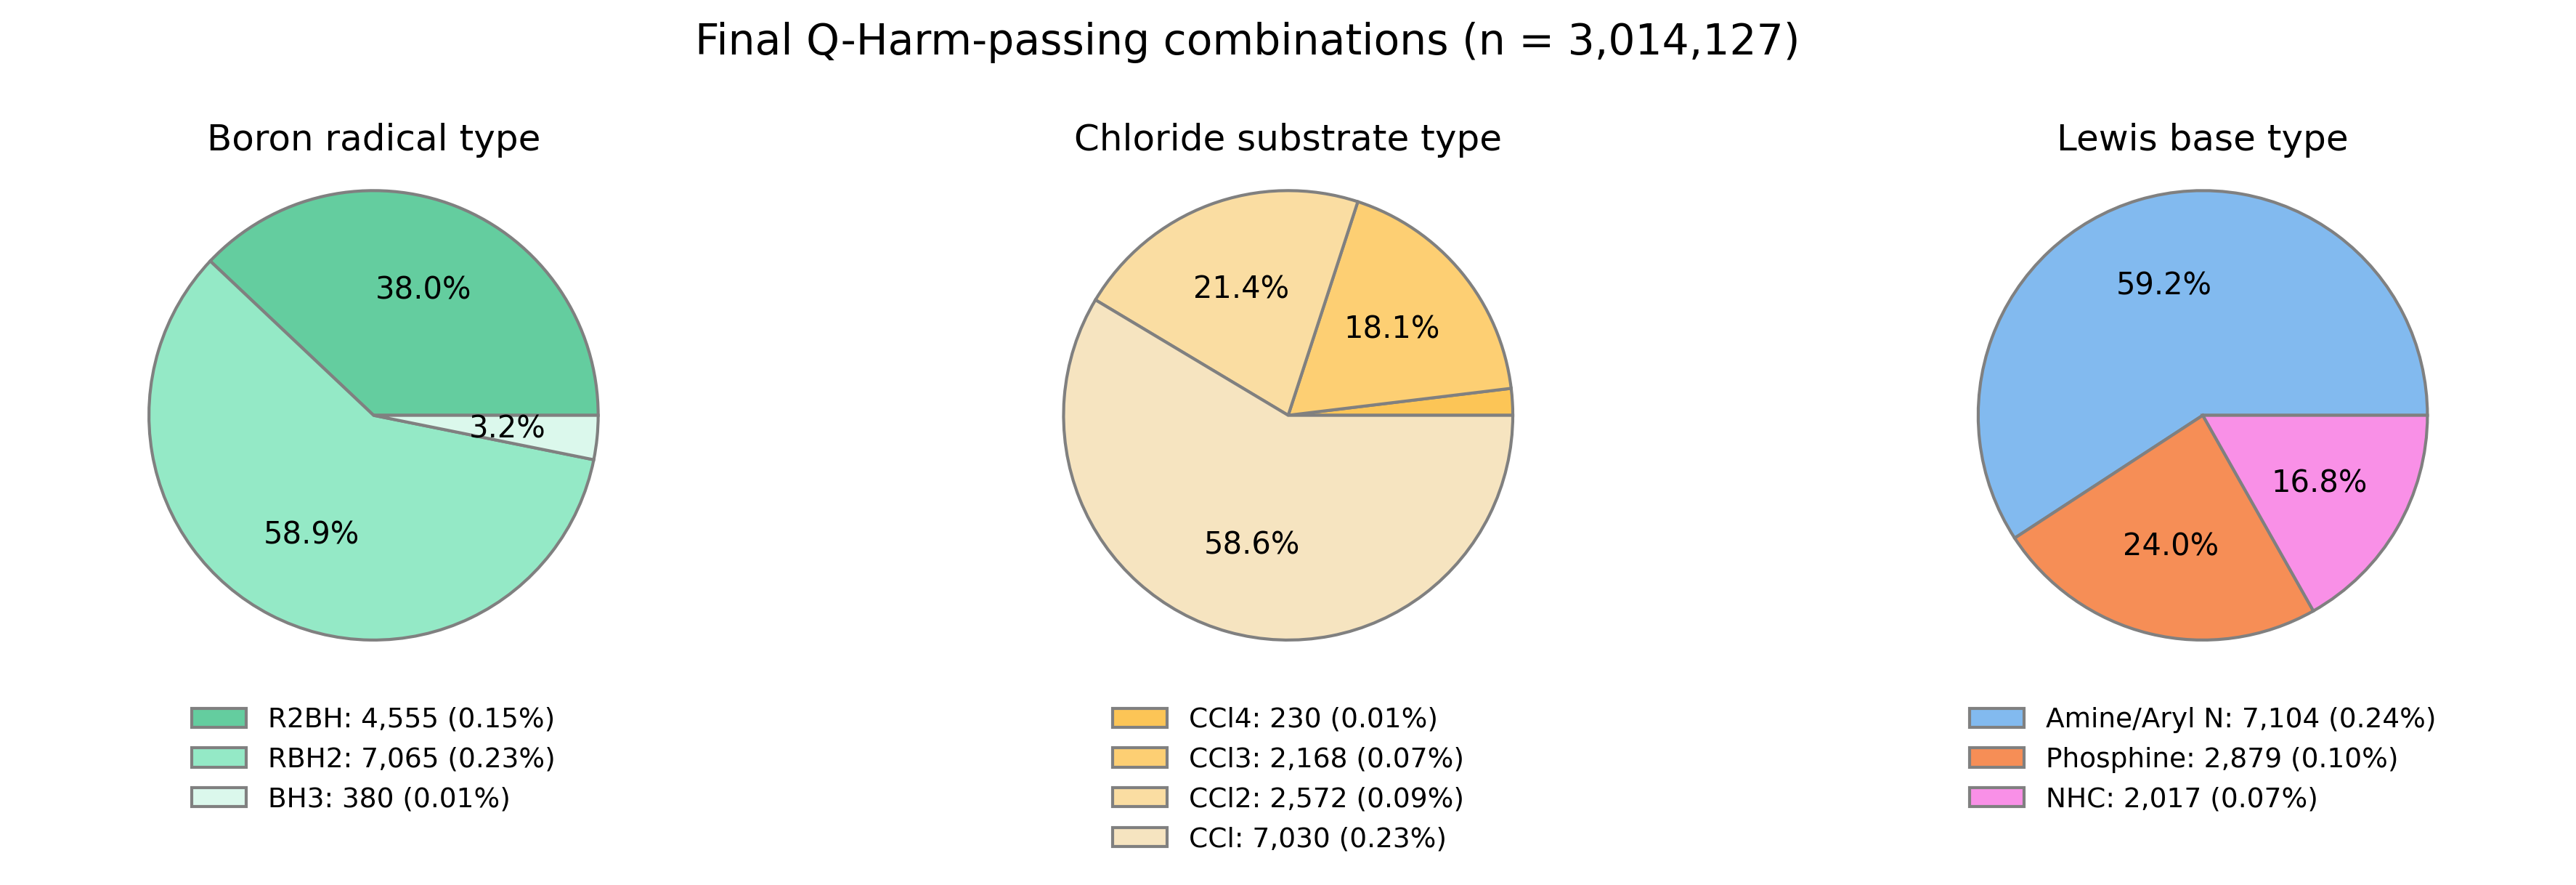

   Type-distribution figure saved: d:\OneDrive_all\OneDrive\Work\work_part\22.Borane_Radical_Database\Figure\OtherFigure_QHARM_filtered_type_distribution.png


In [17]:
all_type_df = pd.read_csv("Data\csvs\First_12000.csv")
all_type_df["B_type"] = bn_type_df["B_smiles"].map(get_boron_type)
all_type_df["LB_type"] = all_type_df["N_Index"].map(get_lb_type)
all_type_df["Cl_type"] = all_type_df["Cl_smiles"].map(get_cl_substrate_type)

b_type_counts = weighted_type_counts(
    all_type_df["B_type"], np.ones(len(all_type_df["B_type"])), B_TYPE_ORDER, "B"
)
lb_type_counts = weighted_type_counts(
    all_type_df["LB_type"], np.ones(len(all_type_df["LB_type"])), LB_TYPE_ORDER, "LB"
)
cl_type_counts = weighted_type_counts(
    all_type_df["Cl_type"], np.ones(len(all_type_df["Cl_type"])), CL_SUBSTRATE_TYPE_ORDER, "Cl"
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), dpi=300)
plot_final_type_pie(
    axes[0],
    b_type_counts,
    "Boron radical type",
    ["#3f9d70", "#64cd9f", "#94e9c6", "#dbf8ec"],
)
plot_final_type_pie(
    axes[1],
    cl_type_counts,
    "Chloride substrate type",
    ["#fcc556", "#fdcf73", "#fadda2", "#f6e4c0"],
)
plot_final_type_pie(
    axes[2],
    lb_type_counts,
    "Lewis base type",
    ["#82baef", "#f68e56", "#f990e7"],
)
fig.suptitle(
    f"Final Q-Harm-passing combinations (n = {passed_reaction_combinations:,})",
    fontsize=14,
)
fig.subplots_adjust(bottom=0.28, top=0.82, wspace=0.30)
# fig.savefig(TYPE_DISTRIBUTION_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("   Type-distribution figure saved:", TYPE_DISTRIBUTION_FIGURE_PATH)

In [14]:
all_type_df

,B_smiles,B_Index,B_Atomid,N_smiles,N_Index,N_Atomid,Cl_smiles,Cl_Index,Cl_Atomid,B_N_Cl_conf,Cl_r_conf,deltaG_react,G_energy_qharm,deltaG_react_qharm,B_type,LB_type,Cl_type
0,B,388,0,CCN(CC)CC,0,2,ClCN1CCCC1,500,0,1,0,-33.510426,-1029.689160,-31.954293,BH3,Amine/Aryl N,CCl
1,B,388,0,CN(C)C,1,1,CNC(c1ccccc1)C(Cl)Cl,466,10,0,0,-41.280541,-1525.015160,-43.522449,BH3,Amine/Aryl N,CCl2
2,B,388,0,CN(C)C,1,1,Nc1nc(=O)c(Cl)c[nH]1,474,6,0,0,-23.956270,-1054.879910,-25.620507,BH3,Amine/Aryl N,CCl
3,B,388,0,CN(C)C,1,1,C=C(C)Cl,475,3,0,0,-28.161022,-777.865147,-29.443907,BH3,Amine/Aryl N,CCl
4,B,388,0,CN(C)C,1,1,C=CC(=C)Cl,476,4,0,0,-38.631487,-815.945514,-40.008991,BH3,Amine/Aryl N,CCl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,BC(F)(F)F,439,0,Fc1nc(F)nc(F)n1,332,2,ClCc1ccccc1,552,0,0,0,-19.950672,-1672.261847,-18.642504,RBH2,Amine/Aryl N,CCl
11996,C=CBC,440,2,O=Cc1ccncc1,245,5,ClC(c1ccccc1)(c1ccccc1)c1ccccc1,510,0,1,0,-17.133574,-1697.422436,-20.097043,RBH2,Amine/Aryl N,CCl
11997,C=CBC,440,2,Cc1cc(C#N)cc(C)n1,264,9,CC(=O)C(Cl)(Cl)Cl,443,4,1,0,-14.818224,-2133.731314,-15.212949,RBH2,Amine/Aryl N,CCl3
11998,COBC#N,441,2,Nc1ccncc1,387,4,O=C=NC(Cl)(Cl)Cl,597,4,0,0,-35.494726,-2123.228783,-34.008129,RBH2,Amine/Aryl N,CCl3
